In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


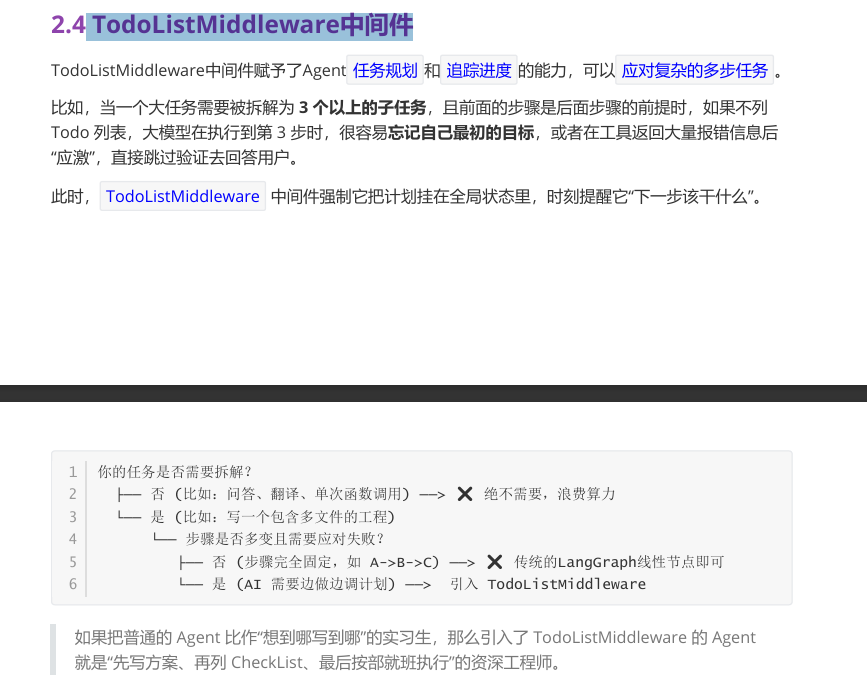

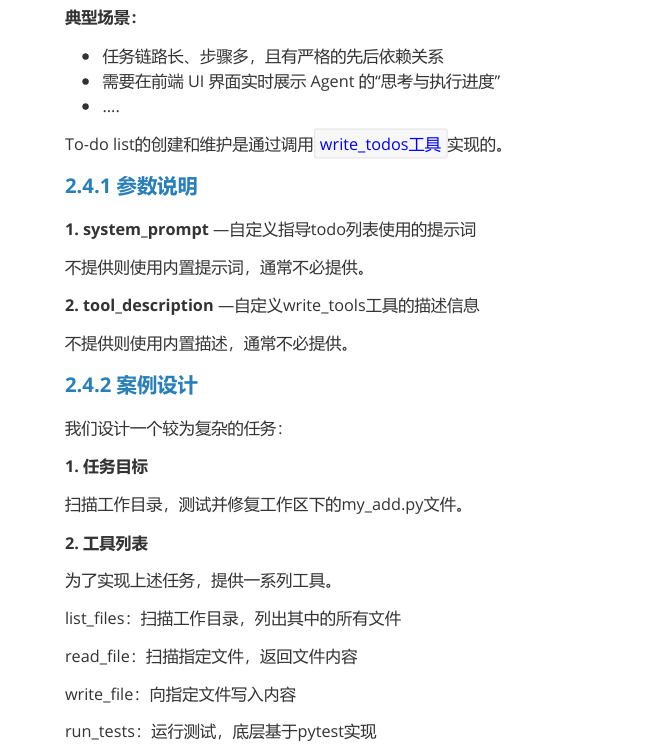

2.4.3 代码
1、环境准备
在项目根目录下创建todo_workspace作为工作空间
在该目录下创建my_add.py，写入以下内容

我们提供的测试工具是基于pytest实现的，pytest用法如下
在PyCharm中打开终端，依次执行命令

(new_torch) PS C:\Users\Lenovo\OneDrive\文档\AI\langchain> conda activate langchain
(langchain) PS C:\Users\Lenovo\OneDrive\文档\AI\langchain> cd.\todo_workspace\
(langchain) PS C:\Users\Lenovo\OneDrive\文档\AI\langchain\todo_workspace>

然后执行
pytest -q


1. pytest会扫描目录下所有以
test_ 开头或以
_test 结尾的文件，视为测试文件
2. 然后执行测试文件中所有以
test 开头的函数
3. 执行出错会打印到控制台，如上所示
4. 测试函数的逻辑是调用my_add.py中的add函数，得不到符合预期的结果则抛出异常。

2、业务代码
提供工具列表

In [2]:
from langchain.tools import tool
from pathlib import Path
import subprocess

WORKSPACE = Path("../todo_workspace")


@tool
def list_files(path: str = ".") -> str:
    """
    列出工作区指定目录下的文件和子目录。path 只能是相对路径。

    Args:
        path: 工作区下的相对路径，一定指向目录，默认为.，表示工作区根路径，不能访问工作区外的目录
     """
    target = (WORKSPACE / path).resolve()
    workspace_root = WORKSPACE.resolve()
    if not str(target).startswith(str(workspace_root)):
        return "错误：只允许访问工作区内的目录。"
    if not target.exists():
        return f"错误：目录不存在: {path}"
    if not target.is_dir():
        return f"错误：不是目录: {path}"
    items = sorted(target.iterdir(), key=lambda p: (p.is_file(),
                                                    p.name.lower()))
    if not items:
        return f"目录为空: {path}"
    lines = []
    for item in items:
        rel = item.relative_to(workspace_root)
        kind = "[DIR]" if item.is_dir() else "[FILE]"
        lines.append(f"{kind} {rel.as_posix()}")
    return "\n".join(lines)


@tool
def read_file(path: str) -> str:
    """
    读取工作区中的文本文件内容。path 只能是相对路径。

    Args:
        path: 工作区内的文件名
    """
    file_path = (WORKSPACE / path).resolve()
    if not str(file_path).startswith(str(WORKSPACE.resolve())):
        return "错误：只允许读取工作区内的文件。"
    if not file_path.exists():
        return f"错误：文件不存在: {path}"
    return file_path.read_text(encoding="utf-8")


@tool
def write_file(path: str, content: str) -> str:
    """
    写入工作区中的文本文件。path 只能是相对路径。
    Args:
        path: 工作区内的文件名
        content: 写入文件的内容
    """
    file_path = (WORKSPACE / path).resolve()
    if not str(file_path).startswith(str(WORKSPACE.resolve())):
        return "错误：只允许写入工作区内的文件。"
    file_path.write_text(content, encoding="utf-8")
    return f"已写入文件: {path}"


@tool
def run_tests() -> str:
    """
    在工作区运行 pytest -q，并返回输出。不接收任何参数，返回格式为
    returncode=0|1
    STDOUT:
    STDERR:
    """
    try:
        result = subprocess.run(
            ["pytest", "-q"],
            cwd=str(WORKSPACE),
            capture_output=True,
            text=True,
            timeout=20,
        )
        return (
            f"returncode={result.returncode}\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )
    except Exception as e:
        return f"运行测试失败: {e}"

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware
from langchain.messages import HumanMessage
from rich import print as rprint

# 1. 初始化 Agent
agent = create_agent(
    model=model,
    # write_todos 等工具，TodoListMiddleware 需要配合这些工具使用
    tools=[list_files, read_file, write_file, run_tests],
    # 引入 Todo 列表中间件
    middleware=[TodoListMiddleware()],
    system_prompt=(
        "你是一个代码修复助手。遇到多步骤任务时，先使用 write_todos 制定待办事项；"
        "然后读取文件、修复代码并运行测试。工作全部在工作区下进行。"
    ),
)
# 2. 使用invoke进行同步调用
print("正在执行 Agent 任务...")
final_state = agent.invoke(
    {
        "messages": [
            HumanMessage(content="请测试并修复工作区下 my_add.py 文件中的代码")
        ]
    }
)
rprint(final_state)
# 3. 直观展示中间件产生的数据结果
print("\n" + "="*20 + " 1. 中间件拦截到的 TODO 列表 " + "="*20)

# TodoListMiddleware 运行期间，会自动将规划好的步骤注入到 state 的 "todos" 字段中
todos = final_state.get("todos", [])

if todos:
    for i, item in enumerate(todos, 1):
        # 兼容中间件可能返回的不同字典结构
        content = item.get("content") or item.get("task") or item.get("text") or str(item)
        status = item.get("status", "unknown")
        print(f"{i}. [{status}] {content}")
else:
    print("未检测到待办事项（可能 Agent 认为不需要规划，或未触发 write_todos 工具）")


print("\n" + "="*20 + " 2. Agent 最终修复回复 " + "="*20)
# 获取对话历史中的最后一条消息（即 Agent 的最终总结）
if final_state.get("messages"):
    print(final_state["messages"][-1].content)

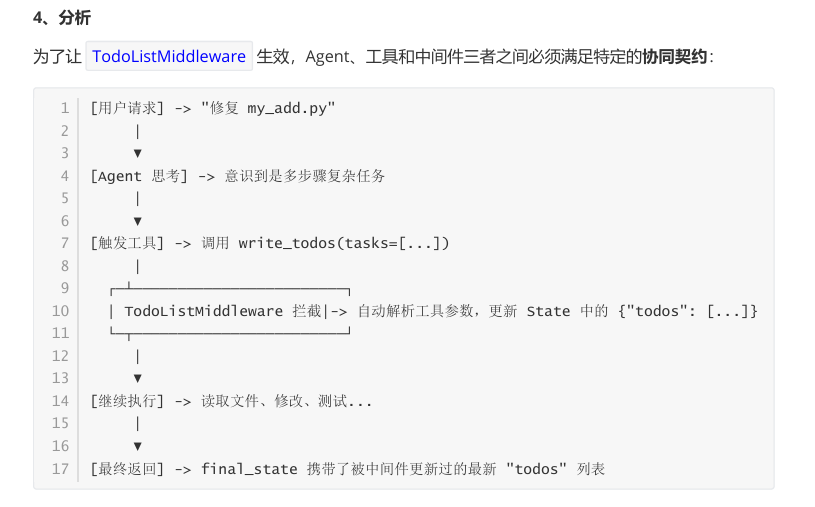
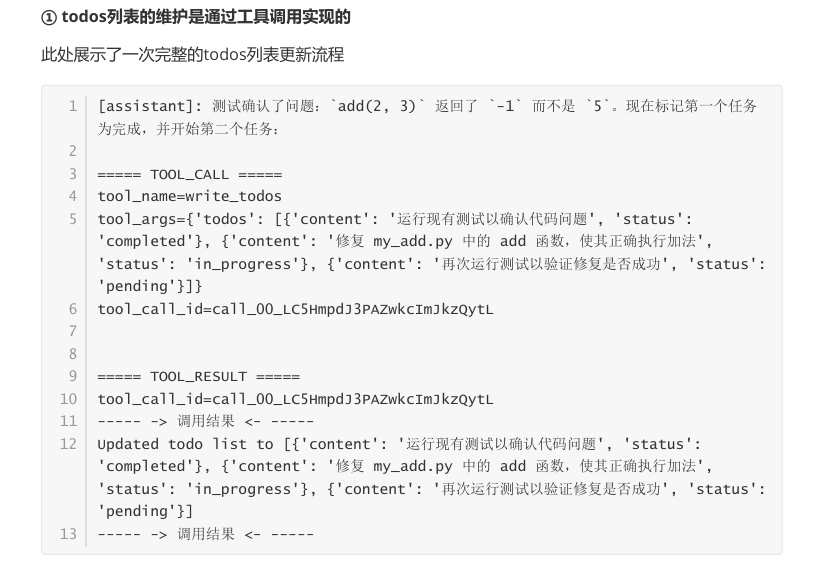
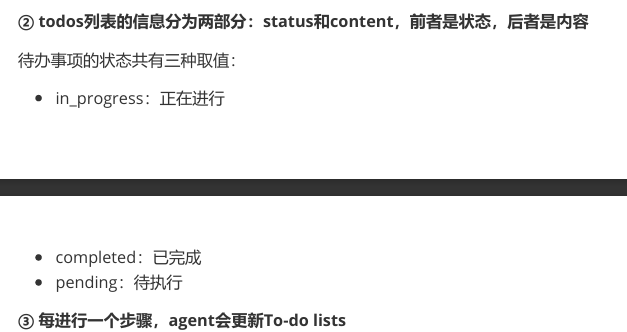